<a href="https://colab.research.google.com/github/Sricharan-rec/Gen-AI_Lab-AD23633/blob/main/genA__Exp_6b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Exp_6b

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


SIMPLIFIED LLM PROMPTING TECHNIQUES EXPERIMENT - GSM8K Dataset

[STEP 1] Loading GSM8K dataset...
✔ Dataset loaded
✔ Questions selected: 5

[STEP 2] Loading FLAN-T5 model...
✔ Model loaded successfully

[STEP 3] Running experiment...

Processing sample 1/5...
True answer: 18.0
Zero-shot: 3
Few-shot: She sells the remainder for 3 * 4 = $12. She sells the remainder for 4 * 2 = $12. She makes $12 / 4 = $2 per egg. She makes $2 / egg * $2 = $2 per egg. She makes $2 / egg * $2 = $2 per egg. She makes $2 / egg * $2 = $2 per egg. She makes $2 / egg * $2 = $2 per egg. She makes $2 / egg * $2 = $2 per egg.
CoT: She sells the remainder at the farmers' market for $2 per fresh duck egg. She makes $2 per duck egg per day for a total of 16 eggs * $2 per duck egg = $120. She makes $2 per duck egg per day for a total of 4 eggs * $2 per duck egg = $120. She makes $2 per duck egg per day for a total of 4 eggs * $2 per duck egg = $120.
Processing sample 2/5...
True answer: 3.0
Zero-shot: 2
Few-shot: 2 * 

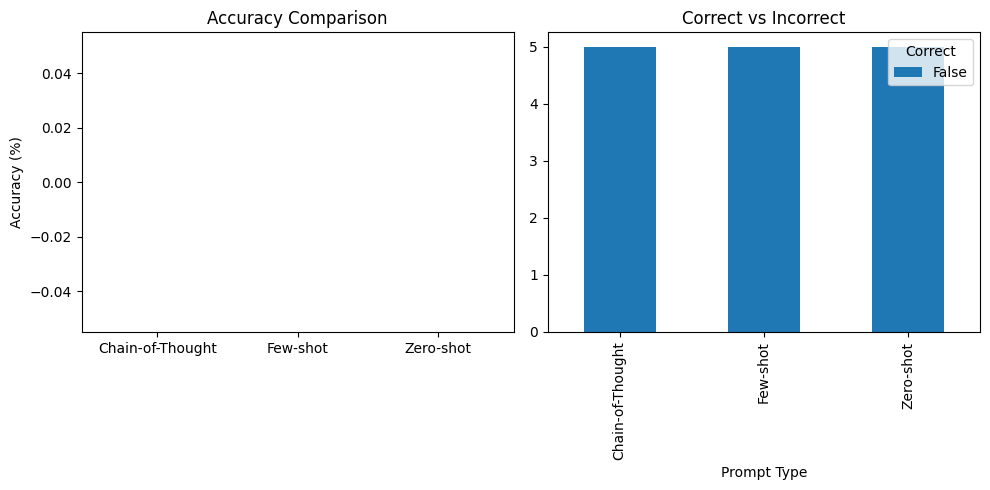

In [ ]:
# ============================
# STEP 0: FIX ENVIRONMENT
# ============================
!pip install transformers==4.35.0 datasets pandas matplotlib -q

# ⚠️ IMPORTANT:
# After running this cell:
# Runtime → Restart runtime → Run again

# ============================
# IMPORTS
# ============================
import re
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

print("="*80)
print("SIMPLIFIED LLM PROMPTING TECHNIQUES EXPERIMENT - GSM8K Dataset")
print("="*80)

# ============================
# STEP 1: LOAD DATASET
# ============================
print("\n[STEP 1] Loading GSM8K dataset...")
dataset = load_dataset("openai/gsm8k", "main")
samples = dataset["test"].select(range(5))   # increase to 10 if needed

print("✔ Dataset loaded")
print("✔ Questions selected:", len(samples))

# ============================
# STEP 2: LOAD MODEL
# ============================
print("\n[STEP 2] Loading FLAN-T5 model...")

model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")

generator = pipeline(
    "text2text-generation",
    model=model,
    tokenizer=tokenizer
)

print("✔ Model loaded successfully")

# ============================
# PROMPTS (IMPROVED)
# ============================
def zero_shot_prompt(q):
    return f"""
Solve the math problem and give ONLY the final numeric answer.

Question: {q}

Final Answer:
"""

def few_shot_prompt(q):
    return f"""
Solve step by step.

Example 1:
Question: Ravi has 3 apples and buys 2 more. How many apples?
Solution: 3 + 2 = 5
Final Answer: 5

Example 2:
Question: There are 4 pencils in one box. If there are 3 boxes, how many pencils?
Solution: 4 × 3 = 12
Final Answer: 12

Now solve:

Question: {q}
Solution:
Final Answer:
"""

def cot_prompt(q):
    return f"""
Solve the problem step by step carefully.

After solving, write:
Final Answer: <number>

Question: {q}
"""

# ============================
# RESPONSE FUNCTION
# ============================
def get_response(prompt):
    output = generator(
        prompt,
        max_length=128,
        do_sample=False
    )
    return output[0]["generated_text"]

# ============================
# NUMBER EXTRACTION
# ============================
def extract_number(text):
    if text is None:
        return None

    text = text.replace(",", "")

    # priority: Final Answer
    match = re.search(r'final answer[:\s]*([-+]?\d+\.?\d*)', text.lower())
    if match:
        return float(match.group(1))

    # fallback
    nums = re.findall(r'-?\d+\.?\d*', text)
    if nums:
        return float(nums[-1])

    return None

# ============================
# CORRECTNESS CHECK
# ============================
def is_correct(true, pred):
    if true is None or pred is None:
        return False
    return abs(float(true) - float(pred)) < 1e-3

# ============================
# STEP 3: RUN EXPERIMENT
# ============================
print("\n[STEP 3] Running experiment...\n")

results = []

for i, sample in enumerate(samples):
    q = sample["question"]
    true_answer = extract_number(sample["answer"])

    print(f"Processing sample {i+1}/{len(samples)}...")
    print("True answer:", true_answer)

    # Zero-shot
    z_res = get_response(zero_shot_prompt(q))
    z_pred = extract_number(z_res)
    print("Zero-shot:", z_res)

    # Few-shot
    f_res = get_response(few_shot_prompt(q))
    f_pred = extract_number(f_res)
    print("Few-shot:", f_res)

    # Chain-of-Thought
    c_res = get_response(cot_prompt(q))
    c_pred = extract_number(c_res)
    print("CoT:", c_res)

    results.extend([
        {"Sample": i+1, "Prompt Type": "Zero-shot", "True Answer": true_answer, "Predicted": z_pred},
        {"Sample": i+1, "Prompt Type": "Few-shot", "True Answer": true_answer, "Predicted": f_pred},
        {"Sample": i+1, "Prompt Type": "Chain-of-Thought", "True Answer": true_answer, "Predicted": c_pred}
    ])

print("\n✔ Experiment completed")

# ============================
# STEP 4: ANALYSIS
# ============================
print("\n[STEP 4] Analyzing results...")
print("="*80)

df = pd.DataFrame(results)
df["Correct"] = df.apply(lambda x: is_correct(x["True Answer"], x["Predicted"]), axis=1)

print("\nDETAILED RESULTS:\n")
print(df)

accuracy = df.groupby("Prompt Type")["Correct"].mean() * 100

print("\nAccuracy:")
print(accuracy)

total = len(df)
correct = df["Correct"].sum()

print("\nTotal predictions:", total)
print("Overall accuracy:", round(correct/total*100, 2), "%")
print("Overall correct:", correct, "/", total)

best_method = accuracy.idxmax()
print("\nBest performing method:", best_method, f"({accuracy.max():.1f}%)")

# ============================
# STEP 5: VISUALIZATION
# ============================
print("\n[STEP 5] Creating visualization...")

plt.figure(figsize=(10,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.bar(accuracy.index, accuracy.values)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy (%)")

# Correct vs Incorrect
plt.subplot(1,2,2)
counts = df.groupby(["Prompt Type","Correct"]).size().unstack(fill_value=0)
counts.plot(kind="bar", ax=plt.gca())
plt.title("Correct vs Incorrect")

plt.tight_layout()
plt.show()